---
<a id = "part_1"></a>
## Part 1. Understanding compartmental models (26 total points)



The movement of pollutants through different stages in the environment can be modeled using compartments. 

Initially, pollutants are released as emissions ($E$). Over time, these emissions decrease as they transition into the atmosphere ($A$). Once in the atmosphere, pollutants build up but are simultaneously reduced through two processes: some pollutants settle out of the air and deposit on surfaces ($D$), while others are naturally cleaned by environmental elements such as trees and plants (Untracked). Eventually, the pollutants that settle out contribute to a buildup of deposited pollutants on the ground or water. The balance of how quickly pollutants are emitted, how they accumulate in the atmosphere, and how they are removed by natural processes and deposition determines the overall distribution and movement of pollution through these stages.

We can sketch out a compartmental model for this system with flux parameters $k_1$, $k_2$, and $k_3$ as shown below:

<img src="https://i.postimg.cc/nVNWzDMy/Screenshot-2024-11-06-at-09-19-45.png" alt="EAD model" width="500"/>

You will need to conceptually analyze this model and write down the model as ordinary differential equations (ODEs).

&#9989;&nbsp; **Part 1.1 (5 points)**

Describe in the cell below: how many compartments there are in the model, and what each of the compartments stands for. 

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Part 1.2 (9 points)**

Describe in the cell below the interpretation of each of the following parameters
- $k_1$
- $k_2$
- $k_3$

in terms **what rate it represents** and **which part of the polluting process** it describes.

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Part 1.3 (6 points)**

Answer in the cell below: Which of the following parameters $k_1$, $k_2$, or $k_3$ should we attempt to control in order to mitigate pollution? Should that parameter be large or small? Why?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Part 1.4 (6 points)**

In the cell below, write down the ordinary differential equations associated with this compartmental model.


<font size=6 color="#009600">&#9998;</font> *Put your answer here*

<a id="part_2"></a>
## Part 2. Solving differential equations numerically (26 total points)

In previous assignments, you have used `solve_ivp` to compute the numeric solution of the logistic model of the growth of a single population. Recall, the Logistic population model is described by the following differential equations:

\begin{equation}
\frac{dP}{dt} = kP\Big(1-\frac{P}{C}\Big),
\end{equation}

where $P =$ population, $k =$ growth rate, and $C =$ the carrying capacity. 

Examples code for computing the solution for for $P_0 =0.1$ billion (initial population), $k=1$, and $C =1$ billion is provided below:

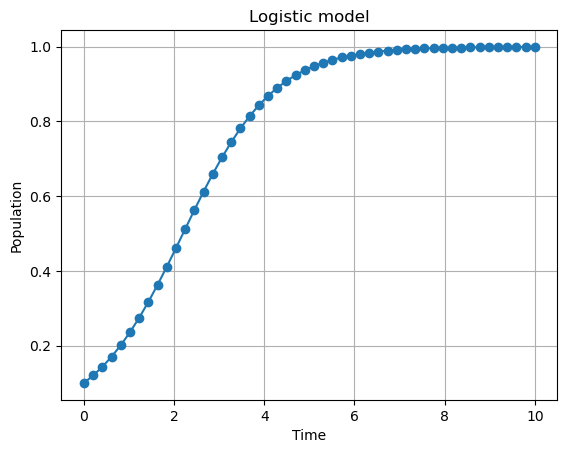

In [2]:
# example code to compute a numeric solution of the logistic model
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# define the derivative
def logistic(time, current_state):
    p = current_state   
    dpdt = p*(1-p)    
    return dpdt

# compute numeric solution
initial_p = [0.1]
time = np.linspace(0,10,50)

result = solve_ivp(logistic, (0,20), initial_p, t_eval = time)

# unpack solution
numerical_p = result.y[0,:]

fig = plt.figure()
plt.plot(time, numerical_p, 'o-')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic model')
plt.grid()
plt.show()

Now you wonder: what happens if there are two different species competing for the same resources? (Such as the great white sharks and the seven-gill sharks &#x1F609;) How would the population growth of one species interfere with that of the other? 

Luckily, such models already exist. One of them is a generalization of the logistic model to take into account resource competition between two species $u$ and $v$ and we have the following competitive Lotka-Volterra model:

$$ \frac{du}{dt} = r_1u(1-(\frac{u +a_{12} v}{K_1}))$$
$$ \frac{dv}{dt} = r_2v(1 -(\frac{v + a_{21}u}{K_2})).$$


Here, $a_{12}$ represents the competitive effect species $v$ has on the population of species $u$ and $a_{21}$ represents the competitive effect species u has on the population of species v. These values do not have to be equal. Because this is the competitive version of the model, all interactions must be harmful (competition) and therefore all a-values are positive.

### Foxes and Coyotes

Let's apply this model to two competitive predators, Red Foxes and Coyotes. Coyotes will kill foxes to stop them from hunting in their territory. Here's [an article from Smithsonian magazine](https://www.smithsonianmag.com/science-nature/foxes-and-coyotes-are-natural-enemies-or-are-they-180968424/) that describes how that is not happening in urban areas. 

To make our model, we first rescale the equations and replace the variables with Foxes (`F`) and Coyotes (`C`) for the populations of the two species.


After rescaling, the **two species competitive Lotka-Volterra model** can become a simplified model:
\begin{align}
\frac{dF}{dt} &= F(1-F -\alpha C)  &(1)\\
\frac{dC}{dt} &= rC(1 -C-\beta F). &(2)
\end{align}

We say that the competition for the foxes `F` (resp. for the coyotes `C`) is **strong** if $\alpha > 1$ (resp. $\beta > 1$). We say that the competition for the foxes `F` (resp. for the coyotes `C`) is **weak** if $0 < \alpha < 1$ (resp. $0 < \beta< 1$).

*NOTE:** In these rescaled equations, the relationship between `F` and `C` is proportional. So if we set `F=1` and `C=0.5`, then there are twice as many foxes as coyotes in our model to start.

**Your job for this part of the assignment is implementing and computing the numeric solutions for the two species competitive Lotka-Volterra model as described by equations 1 and 2 above. You can do so by adapting the code for the logistic model above.**

&#9989;&nbsp; **Part 2.1 (8 points)**  
Define the derivative function for the two species competitive Lotka-Volterra model in the cell below (to be used as an input later for `solve_ivp` -- so pay attention to the format).

In [3]:
# write your function here


&#9989;&nbsp; **Part 2.2 (6 points)**

Using `solve_ivp`, compute the numeric solution for two species competitive Lotka-Volterra model with the parameters $r=1$, $\alpha=2/3,$ $\beta =1/4$, the initial conditions $[F_0,C_0]= [1,.5]$, and the final time equal 20. Unpack the result you get from `solve_ivp` into separate variables `F` and `C`.

In [75]:
# put your code here


&#9989;&nbsp; **Part 2.3 (4 points)**

Plot the solutions of $F$ and $C$ as a function of time in the cell below. Be sure to add appropriate axis labels and legends. 

In [86]:
# put our code here


&#9989;&nbsp; **Part 2.4 (2 points)**

When $0 < \alpha <1 $ and $ 0 <\beta <1$, the model is a "weak" competitive Lotka-Volterra model. Check with the plot above to see what will happen as time goes on. What happens to the populations of foxes and coyotes?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Part 2.5 (6 points)**

When $\alpha > 1 $ and $\beta > 1$, the model is a "strong" competitive Lotka-Volterra model. Make a new plot like the one above to see what will happen. Choose `r=1`, `alpha=1.6`, and `beta=1.1`. What happens to the populations of foxes and coyotes?

In [ ]:
## put your code here

<font size=6 color="#009600">&#9998;</font> *Put your answer here*